**Importr necessay libraries**

In [1]:
import warnings
warnings.filterwarnings('ignore') 
# Core Data Manipulation
import pandas as pd
import numpy as np
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Preprocessing & Metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)

# The Champion Algorithm
from xgboost import XGBClassifier

# Deployment / Model Exporting
import joblib 

print("✅ Step 1: Libraries imported successfully.")

✅ Step 1: Libraries imported successfully.


In [2]:
# 2. IMPORT DATASETS
df_train = pd.read_csv('cargo_routing_train.csv')
df_val = pd.read_csv('cargo_routing_validation.csv')
df_test = pd.read_csv('cargo_routing_test.csv')
print(f"   -> Training Data:   {df_train.shape[0]} routes, {df_train.shape[1]} columns")
print(f"   -> Validation Data: {df_val.shape[0]} routes, {df_val.shape[1]} columns")
print(f"   -> Testing Data:    {df_test.shape[0]} routes, {df_test.shape[1]} columns")

   -> Training Data:   14000 routes, 21 columns
   -> Validation Data: 3500 routes, 21 columns
   -> Testing Data:    3500 routes, 21 columns


**Data Cleaning**

In [3]:
# A. Isolate the target and drop non-predictive administrative columns
cols_to_drop = ['record_id', 'timestamp', 'shipment_id', 'candidate_route_id']

# B. Separate Features (X) and Target (y) - PURE REGRESSION
# We keep the exact continuous 'optimization_score'
X_train = df_train.drop(columns=cols_to_drop + ['optimization_score'])
y_train = df_train['optimization_score']

X_val = df_val.drop(columns=cols_to_drop + ['optimization_score'])
y_val = df_val['optimization_score']

X_test = df_test.drop(columns=cols_to_drop + ['optimization_score'])
y_test = df_test['optimization_score']

# C. Secure Label Encoding for XGBoost
categorical_features = ['origin', 'destination', 'cargo_type', 'priority', 'airline', 'season', 'shc_code']
print(f"   -> Encoding text features: {categorical_features}")

# Dictionary to store encoders for the deployment application
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    # Fit ONLY on training data to prevent data leakage
    X_train[col] = le.fit_transform(X_train[col])
    
    # Transform Validation and Test data using the training rules
    X_val[col] = le.transform(X_val[col])
    X_test[col] = le.transform(X_test[col])
    
    label_encoders[col] = le

print("   -> Data cleaning and encoding complete.")

   -> Encoding text features: ['origin', 'destination', 'cargo_type', 'priority', 'airline', 'season', 'shc_code']
   -> Data cleaning and encoding complete.


**Data Visualization**

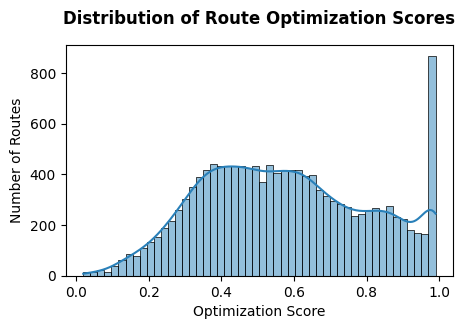

   -> Displayed '1_score_distribution.png'


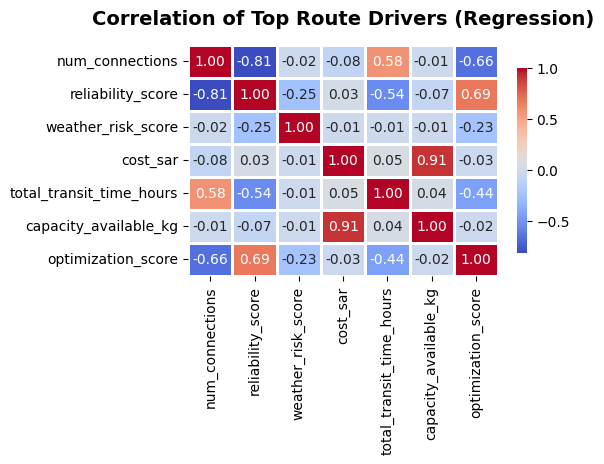

   -> Displayed '2_driver_correlation.png'


In [6]:
plt.figure(figsize=(5, 3))
sns.histplot(y_train, bins=50, kde=True, color='#2980b9')
plt.title('Distribution of Route Optimization Scores', pad=15, fontweight='bold')
plt.xlabel('Optimization Score')
plt.ylabel('Number of Routes')
plt.show()
print("   -> Displayed '1_score_distribution.png'")

# Plot 2: Top Business Drivers Correlation Heatmap
# We focus ONLY on the top numerical drivers identified in your CatBoost/XGBoost testing
temp_train = X_train.copy()
temp_train['optimization_score'] = y_train

top_numerical_drivers = [
    'num_connections', 'reliability_score', 'weather_risk_score', 
    'cost_sar', 'total_transit_time_hours', 'capacity_available_kg', 
    'optimization_score'
]

plt.figure(figsize=(5, 3))
corr_matrix = temp_train[top_numerical_drivers].corr()

# Create a heatmap with a custom logistics-focused color map
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8})
plt.title('Correlation of Top Route Drivers (Regression)', fontsize=14, pad=15, fontweight='bold')
plt.show()
print("   -> Displayed '2_driver_correlation.png'")

**Model training and validation**

In [7]:
# ==========================================
# 5. MODEL TRAINING (XGBOOST REGRESSOR)
# ==========================================
import time
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("\n🧠 Step 5: Training the XGBoost Regressor...")
start_time = time.time()

# Initialize the winning XGBoost architecture
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    objective='reg:squarederror'
)

# Train on historical data
xgb_model.fit(X_train, y_train)

training_time = round((time.time() - start_time) / 60, 2)
print(f"   -> Model training complete in {training_time} minutes.")


# ==========================================
# 6. VALIDATION PERFORMANCE METRICS
# ==========================================
print("\n📊 Step 6: Evaluating on Validation Data (Practice Exam)...")

# Predict ONLY on the validation set
y_pred_val = xgb_model.predict(X_val)

# Calculate exact regression metrics
r2_val = r2_score(y_val, y_pred_val)
mse_val = mean_squared_error(y_val, y_pred_val)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_val, y_pred_val)

# Display Results
print("============================================================")
print("🏆 XGBOOST VALIDATION METRICS")
print("============================================================")
print(f"R-Squared (R²) : {r2_val:.4f}")
print(f"RMSE           : {rmse_val:.4f}")
print(f"MAE            : {mae_val:.4f}")
print(f"MSE            : {mse_val:.4f}")
print("============================================================\n")


🧠 Step 5: Training the XGBoost Regressor...
   -> Model training complete in 0.0 minutes.

📊 Step 6: Evaluating on Validation Data (Practice Exam)...
🏆 XGBOOST VALIDATION METRICS
R-Squared (R²) : 0.6571
RMSE           : 0.1319
MAE            : 0.1016
MSE            : 0.0174



**Testing performance on unseen data**

In [8]:
# ==========================================
# 7. MODEL TESTING & EVALUATION (UNSEEN DATA)
# ==========================================
print("\n🎯 Step 7: Evaluating on Unseen Test Data (The Final Audit)...")

# Predict the exact optimization scores for the Test dataset
y_pred_test = xgb_model.predict(X_test)

# Calculate final regression metrics
r2_final = r2_score(y_test, y_pred_test)
mse_final = mean_squared_error(y_test, y_pred_test)
rmse_final = np.sqrt(mse_final)
mae_final = mean_absolute_error(y_test, y_pred_test)

print("============================================================")
print("🏆 FINAL PRODUCTION METRICS (TEST DATA)")
print("============================================================")
print(f"R-Squared (R²) : {r2_final:.4f}")
print(f"RMSE           : {rmse_final:.4f}")
print(f"MAE            : {mae_final:.4f}")
print(f"MSE            : {mse_final:.4f}")
print("============================================================\n")


# ==========================================
# 8. EXPORT MODEL FOR DEPLOYMENT
# ==========================================
print("💾 Step 8: Exporting Model and Encoders for Deployment...")

import joblib

# 1. Save the trained XGBoost Model
joblib.dump(xgb_model, 'cargo_xgboost_model.pkl')
print("   -> Saved 'cargo_xgboost_model.pkl'")

# 2. Save the Label Encoders Dictionary
# (Crucial: Your deployment app needs this to translate text inputs like "Express" into numbers)
joblib.dump(label_encoders, 'cargo_label_encoders.pkl')
print("   -> Saved 'cargo_label_encoders.pkl'")

print("\n✅ PIPELINE COMPLETE! Your model is ready for deployment.")


🎯 Step 7: Evaluating on Unseen Test Data (The Final Audit)...
🏆 FINAL PRODUCTION METRICS (TEST DATA)
R-Squared (R²) : 0.6455
RMSE           : 0.1327
MAE            : 0.1012
MSE            : 0.0176

💾 Step 8: Exporting Model and Encoders for Deployment...
   -> Saved 'cargo_xgboost_model.pkl'
   -> Saved 'cargo_label_encoders.pkl'

✅ PIPELINE COMPLETE! Your model is ready for deployment.


In [10]:
# ==========================================
# ROUTE SCORE FORENSICS (EXPLAINING THE AI)
# ==========================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import xgboost as xgb
import joblib

print("🔍 Loading Model and Route Data...")

# 1. LOAD THE SAVED BRAIN
try:
    xgb_model = joblib.load('cargo_xgboost_model.pkl')
    label_encoders = joblib.load('cargo_label_encoders.pkl')
    df_test = pd.read_csv('cargo_routing_test.csv')
except FileNotFoundError:
    print("❌ ERROR: Could not find model or data files. Run the training script first.")
    exit()

# 2. SELECT A ROUTE TO INVESTIGATE (Let's look at the first route in the test set)
route_index = 12
route_raw = df_test.iloc[[route_index]].copy()

# Extract the requested raw business metrics for display
actual_score = route_raw['optimization_score'].values[0]
raw_cost = route_raw['cost_sar'].values[0]
raw_time = route_raw['total_transit_time_hours'].values[0]
raw_reliability = route_raw['reliability_score'].values[0]
raw_capacity = route_raw['capacity_available_kg'].values[0]
route_id = route_raw['record_id'].values[0]

# 3. PREPARE THE DATA FOR THE AI
cols_to_drop = ['record_id', 'timestamp', 'shipment_id', 'candidate_route_id', 'optimization_score']
X_single = route_raw.drop(columns=cols_to_drop)

# Keep a dictionary of the original human-readable text before encoding
human_readable_data = X_single.iloc[0].to_dict()

# Encode text to numbers using our saved encoders
categorical_features = ['origin', 'destination', 'cargo_type', 'priority', 'airline', 'season', 'shc_code']
for col in categorical_features:
    X_single[col] = label_encoders[col].transform(X_single[col])

# 4. EXTRACT THE EXACT MATHEMATICAL CONTRIBUTIONS
# Predict the final score
pred_score = xgb_model.predict(X_single)[0]

# Extract the exact feature contributions using XGBoost's native SHAP matrix
# This returns an array where the last number is the baseline score, 
# and the rest are the exact mathematical +/- impacts of each feature.
dmatrix = xgb.DMatrix(X_single)
contributions = xgb_model.get_booster().predict(dmatrix, pred_contribs=True)[0]

base_score = contributions[-1]
feature_impacts = contributions[:-1]

# Calculate the total "push" (absolute sum of all movements) to figure out percentages
total_absolute_impact = np.sum(np.abs(feature_impacts))

# 5. PRINT THE FORENSIC REPORT
print("\n" + "="*60)
print(f"🔎 FORENSIC SCORE BREAKDOWN: {route_id}")
print("="*60)

print(f"🎯 AI Predicted Score : {pred_score:.4f} (Actual: {actual_score:.4f})")
print(f"🏗️ Base Starting Score: {base_score:.4f} (The average route score)\n")

print("📊 REQUESTED RAW METRICS:")
print("-" * 30)
print(f"Cost (SAR)          : {raw_cost:,.2f}")
print(f"Transit Time (hrs)  : {raw_time:.2f}")
print(f"Reliability         : {raw_reliability:.3f}")
print(f"Capacity Available  : {raw_capacity:,.2f} kg\n")

print("⚙️ EXACT FEATURE CONTRIBUTIONS (How we got from Base to Final):")
print("-" * 60)
print(f"{'Feature':<25} | {'Raw Value':<15} | {'Impact':<8} | {'% of Decision'}")
print("-" * 60)

# Build a list to sort features by how much they influenced the decision
impact_details = []
for i, col in enumerate(X_single.columns):
    impact = feature_impacts[i]
    perc = (abs(impact) / total_absolute_impact) * 100
    raw_val = human_readable_data[col]
    impact_details.append((col, raw_val, impact, perc))

# Sort by the most influential feature (highest percentage)
impact_details.sort(key=lambda x: x[3], reverse=True)

for col, raw_val, impact, perc in impact_details:
    # Format the impact string (e.g., +0.0452 or -0.1205)
    impact_str = f"+{impact:.4f}" if impact > 0 else f"{impact:.4f}"
    
    # Truncate raw values if they are long floats
    if isinstance(raw_val, float):
        raw_val_str = f"{raw_val:.2f}"
    else:
        raw_val_str = str(raw_val)
        
    print(f"{col:<25} | {raw_val_str:<15} | {impact_str:<8} | {perc:>5.1f}%")

print("-" * 60)
print("MATH CHECK: Base Score + Sum of Impacts = Predicted Score")
print(f"{base_score:.4f} + ({sum(feature_impacts):.4f}) = {base_score + sum(feature_impacts):.4f}")
print("============================================================\n")

🔍 Loading Model and Route Data...

🔎 FORENSIC SCORE BREAKDOWN: RTE_000888
🎯 AI Predicted Score : 0.9485 (Actual: 0.9900)
🏗️ Base Starting Score: 0.5758 (The average route score)

📊 REQUESTED RAW METRICS:
------------------------------
Cost (SAR)          : 6,016.64
Transit Time (hrs)  : 10.53
Reliability         : 0.990
Capacity Available  : 1,837.17 kg

⚙️ EXACT FEATURE CONTRIBUTIONS (How we got from Base to Final):
------------------------------------------------------------
Feature                   | Raw Value       | Impact   | % of Decision
------------------------------------------------------------
reliability_score         | 0.99            | +0.1365  |  31.6%
num_connections           | 0               | +0.0972  |  22.5%
cost_sar                  | 6016.64         | +0.0474  |  11.0%
weather_risk_score        | 0.17            | +0.0348  |   8.1%
total_transit_time_hours  | 10.53           | +0.0287  |   6.7%
distance_km               | 6189.00         | +0.0199  |   4.6%
lo